# Import danych

In [ ]:
%pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_prognostic = fetch_ucirepo(id=16)

# data
df = breast_cancer_wisconsin_prognostic.data.features
y = breast_cancer_wisconsin_prognostic.data.targets



# Przedstawienie danych

In [ ]:
# variable information
print(breast_cancer_wisconsin_prognostic.variables)

                  name     role         type demographic description units  \
0                   ID       ID      Integer        None        None  None   
1                 Time  Feature      Integer        None        None  None   
2              radius1  Feature   Continuous        None        None  None   
3             texture1  Feature   Continuous        None        None  None   
4           perimeter1  Feature   Continuous        None        None  None   
5                area1  Feature   Continuous        None        None  None   
6          smoothness1  Feature   Continuous        None        None  None   
7         compactness1  Feature   Continuous        None        None  None   
8           concavity1  Feature   Continuous        None        None  None   
9      concave_points1  Feature   Continuous        None        None  None   
10           symmetry1  Feature   Continuous        None        None  None   
11  fractal_dimension1  Feature   Continuous        None        

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Time                198 non-null    int64  
 1   radius1             198 non-null    float64
 2   texture1            198 non-null    float64
 3   perimeter1          198 non-null    float64
 4   area1               198 non-null    float64
 5   smoothness1         198 non-null    float64
 6   compactness1        198 non-null    float64
 7   concavity1          198 non-null    float64
 8   concave_points1     198 non-null    float64
 9   symmetry1           198 non-null    float64
 10  fractal_dimension1  198 non-null    float64
 11  radius2             198 non-null    float64
 12  texture2            198 non-null    float64
 13  perimeter2          198 non-null    float64
 14  area2               198 non-null    float64
 15  smoothness2         198 non-null    float64
 16  compactn

In [ ]:
df.head(10)

,Time,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,tumor_size,lymph_node_status
0,31,18.02,27.60,117.50,1013.0,0.09489,0.1036,0.10860,0.07055,0.1865,...,139.70,1436.0,0.1195,0.1926,0.3140,0.1170,0.2677,0.08113,5.0,5.0
1,61,17.99,10.38,122.80,1001.0,0.11840,0.2776,0.30010,0.14710,0.2419,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,3.0,2.0
2,116,21.37,17.44,137.50,1373.0,0.08836,0.1189,0.12550,0.08180,0.2333,...,159.10,1949.0,0.1188,0.3449,0.3414,0.2032,0.4334,0.09067,2.5,0.0
3,123,11.42,20.38,77.58,386.1,0.14250,0.2839,0.24140,0.10520,0.2597,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,2.0,0.0
4,27,20.29,14.34,135.10,1297.0,0.10030,0.1328,0.19800,0.10430,0.1809,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,3.5,0.0
5,77,12.75,15.29,84.60,502.7,0.11890,0.1569,0.16640,0.07666,0.1995,...,107.30,733.2,0.1706,0.4196,0.5999,0.1709,0.3485,0.11790,2.5,0.0
6,60,18.98,19.61,124.40,1112.0,0.09087,0.1237,0.12130,0.08910,0.1727,...,152.60,1593.0,0.1144,0.3371,0.2990,0.1922,0.2726,0.09581,1.5,NaN
7,77,13.71,20.83,90.20,577.9,0.11890,0.1645,0.09366,0.05985,0.2196,...,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,4.0,10.0
8,119,13.00,21.82,87.50,519.8,0.12730,0.1932,0.18590,0.09353,0.2350,...,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,2.0,1.0
9,76,12.46,24.04,83.97,475.9,0.11860,0.2396,0.22730,0.08543,0.2030,...,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,6.0,20.0


# Rozkład klas

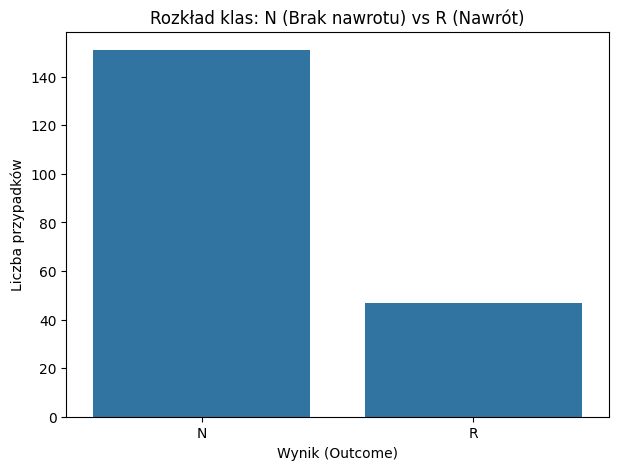

Outcome
N    76.262626
R    23.737374
Name: proportion, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.countplot(x='Outcome', data=y)
plt.title('Rozkład klas: N (Brak nawrotu) vs R (Nawrót)')
plt.xlabel('Wynik (Outcome)')
plt.ylabel('Liczba przypadków')
plt.show()

print(y['Outcome'].value_counts(normalize=True) * 100)

# Mapa brakujących danych

lymph_node_status    4
dtype: int64


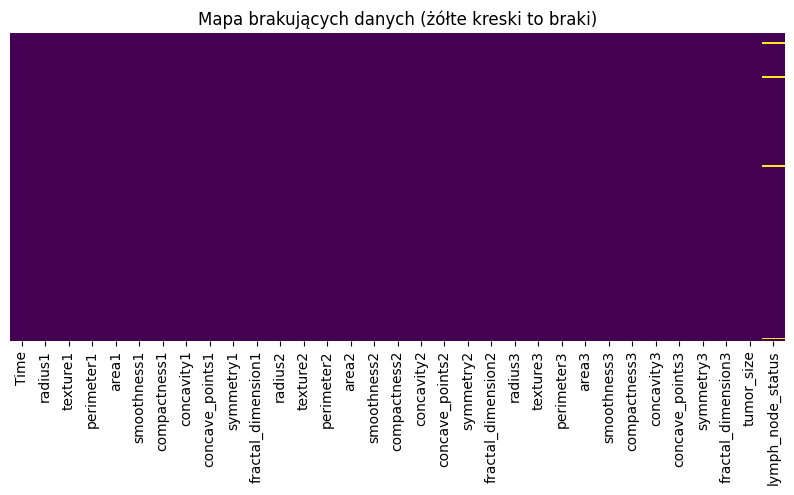

In [ ]:

print(df.isnull().sum()[df.isnull().sum() > 0])

import seaborn as sns
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa brakujących danych (żółte kreski to braki)')
plt.show()

# Macierz korealacji

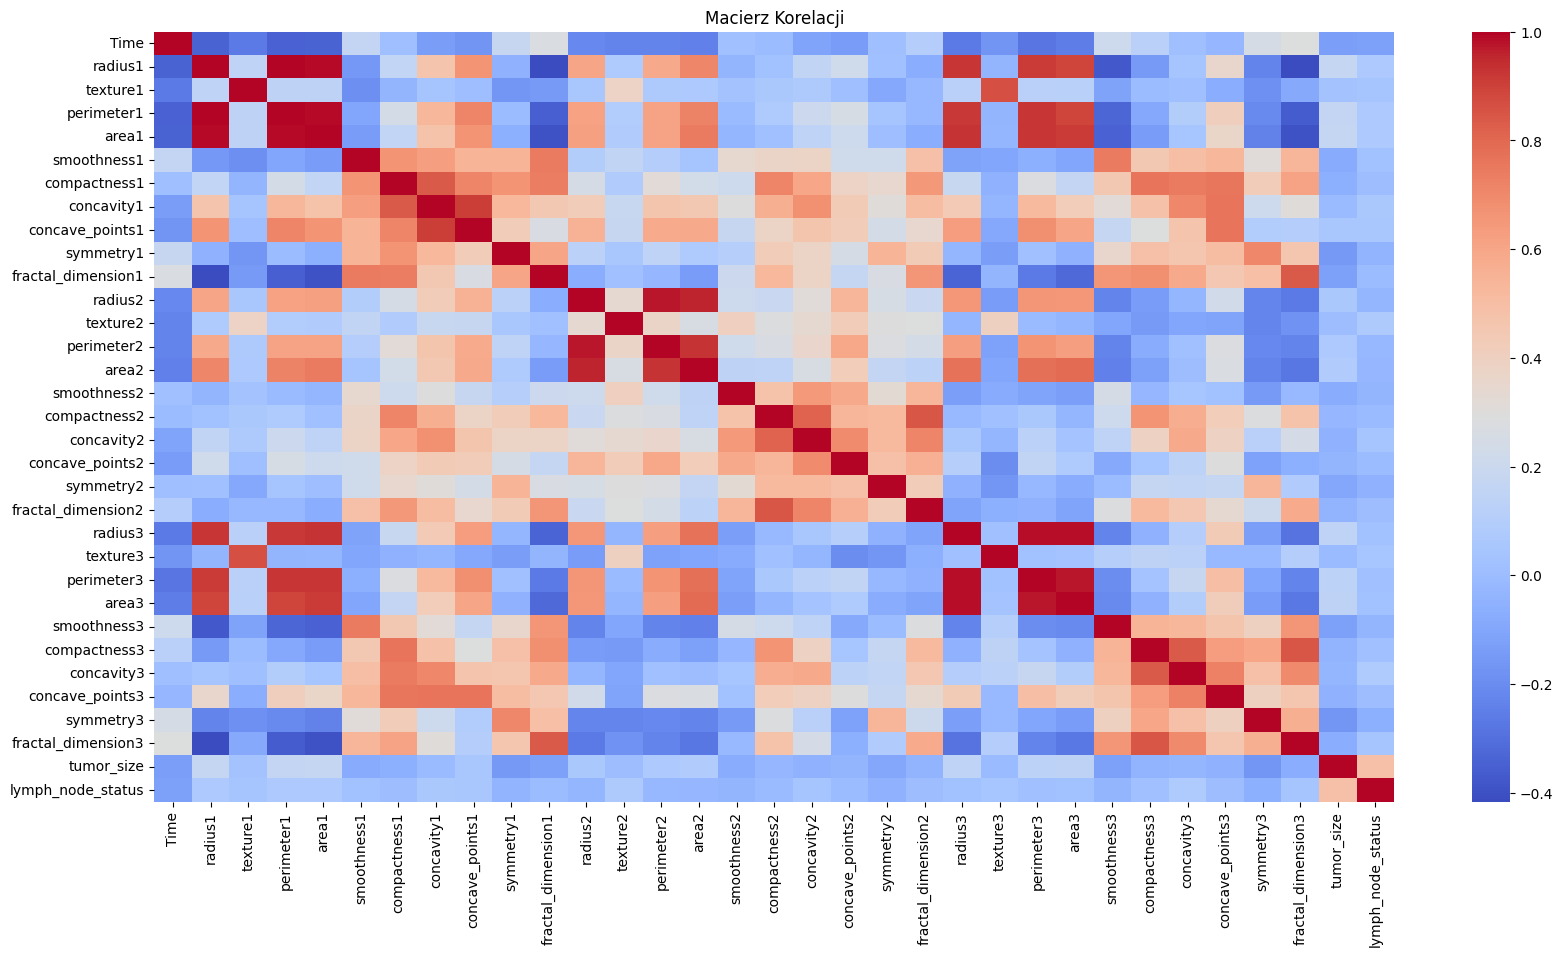

In [ ]:
import numpy as np

plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Macierz Korelacji")
plt.show()

# Rozkład cech

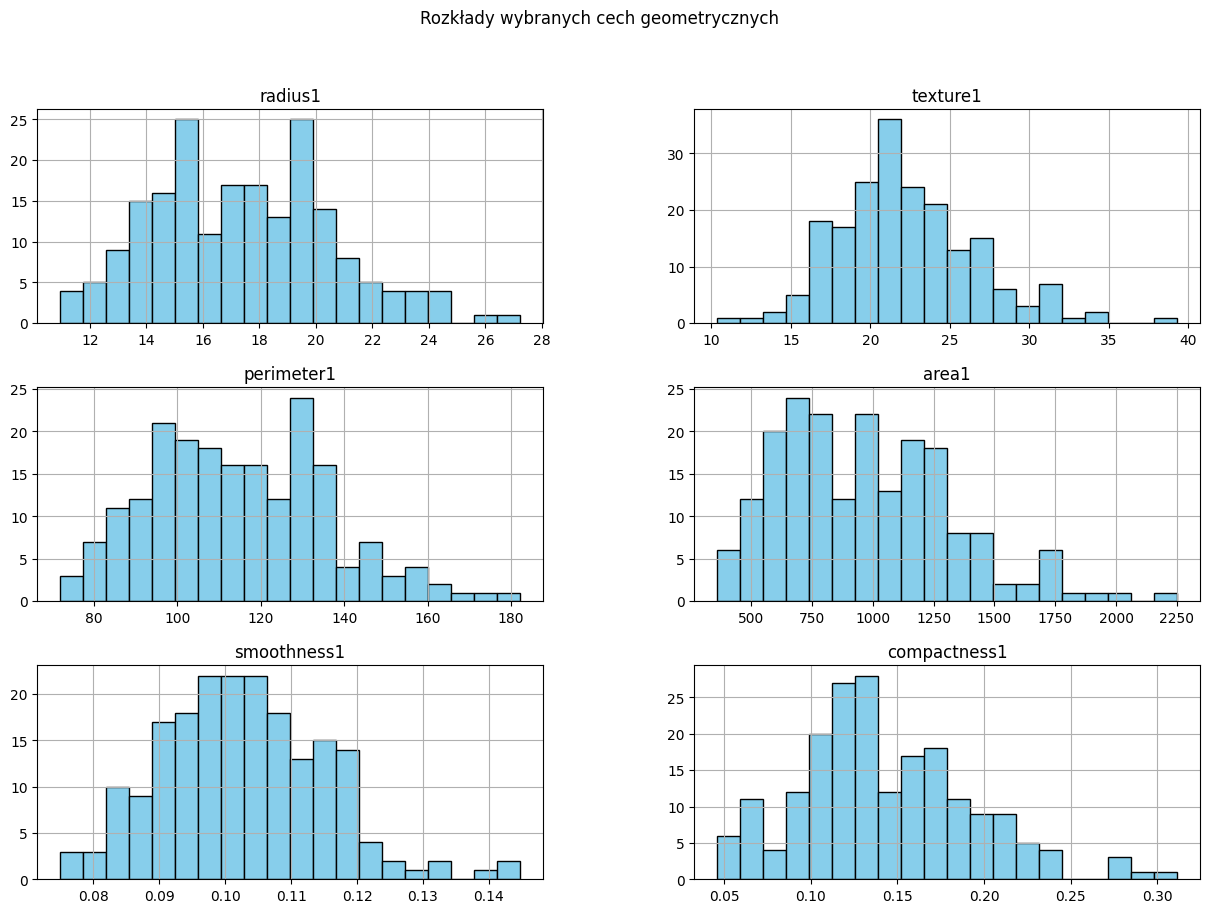

In [ ]:
df.iloc[:, 1:7].hist(figsize=(15, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Rozkłady wybranych cech geometrycznych')
plt.show()

# Czyszcenie danych

In [ ]:
import pandas as pd
import numpy as np

# 1. Naprawa brakujących danych (Imputacja)
df = df.copy()
df['lymph_node_status'] = df['lymph_node_status'].fillna(df['lymph_node_status'].median())

y_numeric = y['Outcome'].map({'N': 0, 'R': 1})

print("Dane gotowe. Liczba braków:", df.isnull().sum().sum())

Dane gotowe. Liczba braków: 0


# Podział danych

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df, y_numeric, test_size=0.25, random_state=42, stratify=y_numeric
)

print(f"Rozmiar treningowy: {X_train.shape[0]}, Rozmiar testowy: {X_test.shape[0]}")

Rozmiar treningowy: 148, Rozmiar testowy: 50


# Grid search dla Drzewa decyzyjnego

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Definicja parametrów do sprawdzenia
param_grid = {
    'max_depth': [3, 5, 10, 15,20,25,30, None],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'min_samples_split': [2, 5, 10,15,20]
}

# Inicjalizacja Grid Search
grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search_dt.fit(X_train, y_train)

print(f"Najlepsze parametry: {grid_search_dt.best_params_}")
print(f"Najlepszy wynik (CV Accuracy): {grid_search_dt.best_score_:.4f}")


Najlepsze parametry: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 15}
Najlepszy wynik (CV Accuracy): 0.7497


# Drzewo decyzyjne

--- WYNIKI DLA NAJLEPSZEGO DRZEWA ---
Accuracy: 0.78
[[35  3]
 [ 8  4]]
              precision    recall  f1-score   support

           0       0.81      0.92      0.86        38
           1       0.57      0.33      0.42        12

    accuracy                           0.78        50
   macro avg       0.69      0.63      0.64        50
weighted avg       0.76      0.78      0.76        50



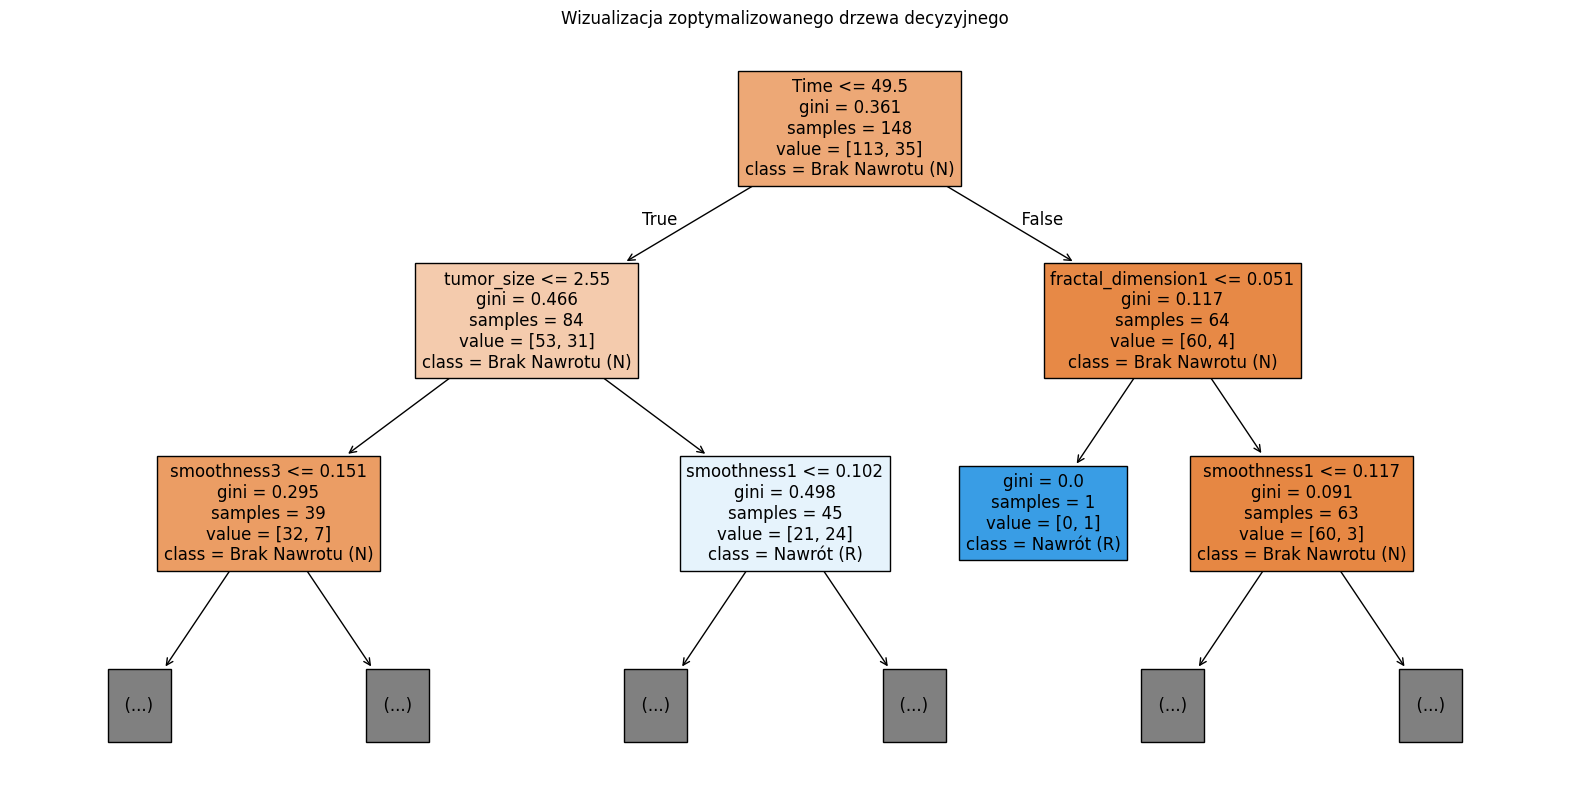

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Pobieramy najlepszy model
best_tree = grid_search_dt.best_estimator_

# Predykcja
predictions = best_tree.predict(X_test)

print('--- WYNIKI DLA NAJLEPSZEGO DRZEWA ---')
print('Accuracy:', accuracy_score(y_test, predictions))
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

# Wizualizacja drzewa
fig = plt.figure(figsize=(20,10))
f_names = list(df.columns)
t_names = ["Brak Nawrotu (N)", "Nawrót (R)"]

tree.plot_tree(best_tree, max_depth=2, feature_names=f_names,
               class_names=t_names, filled=True)
plt.title("Wizualizacja zoptymalizowanego drzewa decyzyjnego")
plt.show()

# Najważniejsze cechy

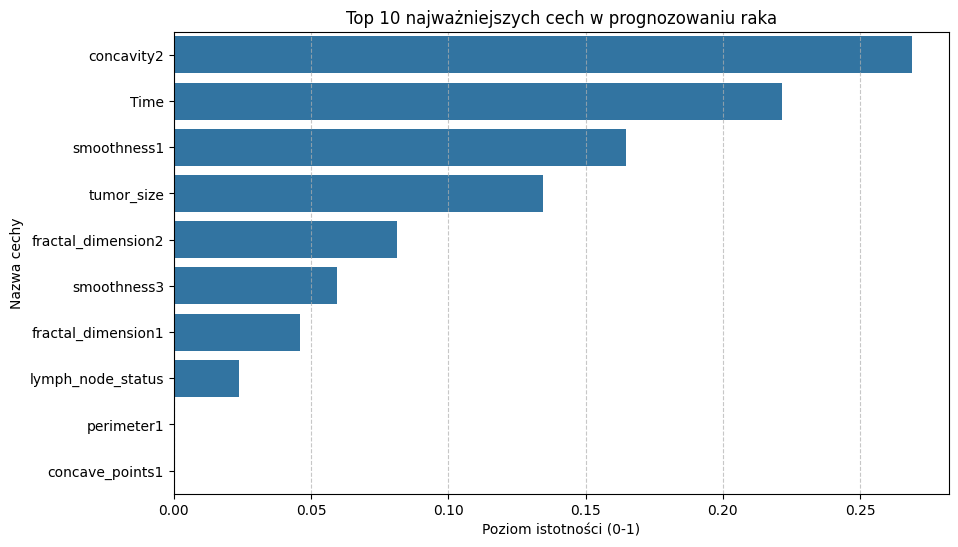

Lista 10 najważniejszych cech:
                 Cecha   Ważność
17          concavity2  0.268836
0                 Time  0.221539
5          smoothness1  0.164574
31          tumor_size  0.134536
20  fractal_dimension2  0.081170
25         smoothness3  0.059616
10  fractal_dimension1  0.045919
32   lymph_node_status  0.023810
3           perimeter1  0.000000
8      concave_points1  0.000000


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


best_model = grid_search_dt.best_estimator_

# 1. Pobranie ważności cech
importances = best_model.feature_importances_
feature_names = df.columns

# 2. Stworzenie DataFrame
feature_importance_df = pd.DataFrame({
    'Cecha': feature_names,
    'Ważność': importances
}).sort_values(by='Ważność', ascending=False)

# 3. Wybranie TOP 10
top_10_features = feature_importance_df.head(10)

# 4. Wykres
plt.figure(figsize=(10, 6))
sns.barplot(x='Ważność', y='Cecha', data=top_10_features)
plt.title('Top 10 najważniejszych cech w prognozowaniu raka')
plt.xlabel('Poziom istotności (0-1)')
plt.ylabel('Nazwa cechy')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Lista 10 najważniejszych cech:")
print(top_10_features)

# Grid search dla boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV


param_grid_boost = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}


grid_search_boost = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_boost,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search_boost.fit(X_train, y_train)

print(f"Najlepsze parametry Boosting: {grid_search_boost.best_params_}")
print(f"Najlepszy wynik CV: {grid_search_boost.best_score_:.4f}")


Najlepsze parametry Boosting: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Najlepszy wynik CV: 0.8041


# Boosting klasyfikacja

--- RAPORT KLASYFIKACJI: GRADIENT BOOSTING ---
Accuracy: 0.8000

Szczegółowy raport:
              precision    recall  f1-score   support

    Brak (N)       0.82      0.95      0.88        38
  Nawrót (R)       0.67      0.33      0.44        12

    accuracy                           0.80        50
   macro avg       0.74      0.64      0.66        50
weighted avg       0.78      0.80      0.77        50



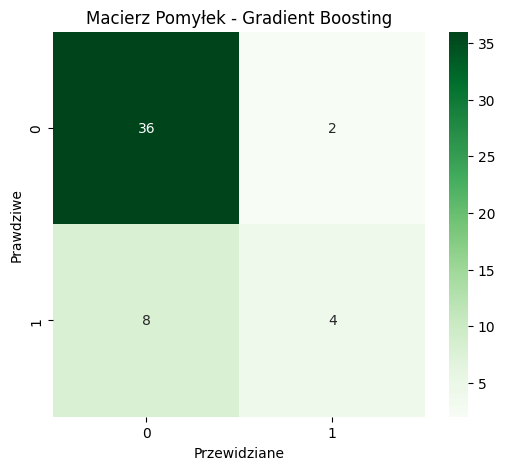

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


best_boost = grid_search_boost.best_estimator_
boost_preds = best_boost.predict(X_test)

print("--- RAPORT KLASYFIKACJI: GRADIENT BOOSTING ---")
print(f"Accuracy: {accuracy_score(y_test, boost_preds):.4f}")
print("\nSzczegółowy raport:")
print(classification_report(y_test, boost_preds, target_names=['Brak (N)', 'Nawrót (R)']))

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, boost_preds), annot=True, fmt='d', cmap='Greens')
plt.title('Macierz Pomyłek - Gradient Boosting')
plt.xlabel('Przewidziane')
plt.ylabel('Prawdziwe')
plt.show()

# Grid search dla SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# 1. Tworzymy Pipeline, który najpierw standaryzuje dane, a potem nakłada SVM.
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=42))
])

# 2. Definicja parametrów do sprawdzenia
# C: parametr regularyzacji (siła kary za błędy)
# gamma: jak szeroki wpływ ma pojedynczy punkt treningowy (dla jądra rbf)
# kernel: rodzaj funkcji jądrowej (liniowa lub rbf)
param_grid_svm = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1],
    'svm__kernel': ['rbf', 'linear']
}

grid_search_svm = GridSearchCV(
    svm_pipeline,
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_svm.fit(X_train, y_train)

print(f"Najlepsze parametry SVM: {grid_search_svm.best_params_}")
print(f"Najlepszy wynik CV: {grid_search_svm.best_score_:.4f}")


Najlepsze parametry SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Najlepszy wynik CV: 0.7908


# SVM klasyfikacja


--- RAPORT KLASYFIKACJI: SVM ---
Accuracy: 0.7600

Szczegółowy raport:
              precision    recall  f1-score   support

    Brak (N)       0.80      0.92      0.85        38
  Nawrót (R)       0.50      0.25      0.33        12

    accuracy                           0.76        50
   macro avg       0.65      0.59      0.59        50
weighted avg       0.72      0.76      0.73        50



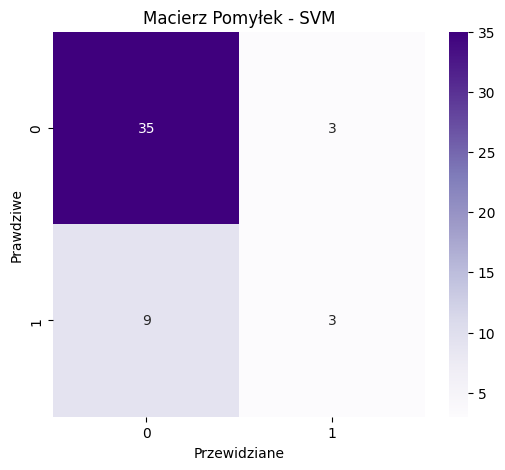

In [ ]:
best_svm = grid_search_svm.best_estimator_
svm_preds = best_svm.predict(X_test)

print("\n--- RAPORT KLASYFIKACJI: SVM ---")
print(f"Accuracy: {accuracy_score(y_test, svm_preds):.4f}")
print("\nSzczegółowy raport:")
print(classification_report(y_test, svm_preds, target_names=['Brak (N)', 'Nawrót (R)']))

# 5. Macierz Pomyłek
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, svm_preds), annot=True, fmt='d', cmap='Purples')
plt.title('Macierz Pomyłek - SVM')
plt.xlabel('Przewidziane')
plt.ylabel('Prawdziwe')
plt.show()

# Selekcja cech

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

estimator = RandomForestClassifier(random_state=42)

selector = RFE(estimator, n_features_to_select=10, step=1)
selector = selector.fit(X_train, y_train)

selected_features = df.columns[selector.support_].tolist()

print("--- WYBRANE CECHY ---")
for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

--- WYBRANE CECHY ---
1. Time
2. texture1
3. smoothness1
4. fractal_dimension1
5. fractal_dimension2
6. area3
7. smoothness3
8. tumor_size


# Drzewo decyzyjne po Selekcji

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_final = DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_split=15, random_state=42)
dt_final.fit(X_train_selected, y_train)

dt_preds = dt_final.predict(X_test_selected)

print("--- WYNIKI: DECISION TREE (10 CECH) ---")
print(f"Accuracy: {accuracy_score(y_test, dt_preds):.4f}")
print("\nRaport klasyfikacji:")
print(classification_report(y_test, dt_preds))

--- WYNIKI: DECISION TREE (10 CECH) ---
Accuracy: 0.7600

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.80      0.92      0.85        38
           1       0.50      0.25      0.33        12

    accuracy                           0.76        50
   macro avg       0.65      0.59      0.59        50
weighted avg       0.72      0.76      0.73        50



# Boosting po selekcji

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Inicjalizacja i trenowanie
boost_final = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42,subsample=0.8)
boost_final.fit(X_train_selected, y_train)

# Predykcja
boost_preds = boost_final.predict(X_test_selected)

print("--- WYNIKI: GRADIENT BOOSTING (10 CECH) ---")
print(f"Accuracy: {accuracy_score(y_test, boost_preds):.4f}")
print("\nRaport klasyfikacji:")
print(classification_report(y_test, boost_preds))

--- WYNIKI: GRADIENT BOOSTING (10 CECH) ---
Accuracy: 0.7600

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.78      0.95      0.86        38
           1       0.50      0.17      0.25        12

    accuracy                           0.76        50
   macro avg       0.64      0.56      0.55        50
weighted avg       0.71      0.76      0.71        50



# SVM po selekcji

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# SVM MUSI mieć standaryzację, więc używamy Pipeline
svm_final = make_pipeline(StandardScaler(), SVC(C=10, gamma=0.01 ,kernel='rbf', probability=True, random_state=42))
svm_final.fit(X_train_selected, y_train)

# Predykcja
svm_preds = svm_final.predict(X_test_selected)

print("--- WYNIKI: SVM (10 CECH + SKALOWANIE) ---")
print(f"Accuracy: {accuracy_score(y_test, svm_preds):.4f}")
print("\nRaport klasyfikacji:")
print(classification_report(y_test, svm_preds))

--- WYNIKI: SVM (10 CECH + SKALOWANIE) ---
Accuracy: 0.7400

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.78      0.92      0.84        38
           1       0.40      0.17      0.24        12

    accuracy                           0.74        50
   macro avg       0.59      0.54      0.54        50
weighted avg       0.69      0.74      0.70        50

